# 東京の気温とCPI分析：過去分析と未来予測

このプロジェクトは1970〜2025年の気象庁気温データと
e-Stat消費者物価指数（CPI）を組み合わせて、
気温とインフレの関係性を分析し、未来予測モデルを構築しました。

## 📑 目次

1. [1. データ取得](#1-データ取得)
   - [1-1. 気温データの取得](#1-1-気温データの取得)
   - [1-2. CPIデータの取得](#1-2-cpiデータの取得)
2. [2. EDA（探索的分析）](#2eda探索的分析)
   - [2-1. 気温の年別トレンド](#2-1-気温の年別トレンド)
   - [2-2. 気温の月別パターン](#2-2-気温の月別パターン)
   - [2-3. 気温の3時期比較](#2-3-気温の3時期比較)
   - [2-4. CPIの年別トレンド](#2-4-cpiの年別トレンド)
   - [2-5. CPIの月別パターン](#2-5-cpiの月別パターン)
   - [2-6. CPIの3時期比較](#2-6-cpiの3時期比較)
3. [3. 相関分析](#3-相関分析)
   - [3-1. 相関分析の基礎](#3-1-相関分析の基礎)
   - [3-2. データの準備と計算](#3-2-データの準備と計算)
   - [3-3. 相関分析の結果と解釈](#3-3-相関分析の結果と解釈)
4. [4. 予測モデル（Prophet）](#4-予測モデルprophet)
   - [4-1. 予測モデルの基礎と目的](#4-1-予測モデルの基礎と目的)
   - [4-2. 気温の予測](#4-2-気温の予測)
   - [4-3. CPIの予測](#4-3-cpiの予測)
   - [4-4. 気温×CPI予測の並行比較](#4-4-気温×cpi予測の並行比較)
5. [5. 結論と今後の課題](#5-結論と今後の課題)
   - [5-1. 55年間の分析から導き出された主な発見](#5-1-55年間の分析から導き出された主な発見)
   - [5-2. 今後の課題と改善方向](#5-2-今後の課題と改善方向)
   - [5-3. 最終的な含意と政策的示唆](#5-3-最終的な含意と政策的示唆)

## 1. データ取得

### 1-1 東京の過去の気温を取得する

気象庁のホームぺ時にアクセス
[過去の気象データ・ダウンロード](https://www.data.jma.go.jp/risk/obsdl/index.php)

東京を選択し、csvダウンロード押下
data.csv が取得できる

![image.png](outputs/highlights/tokyo.temperature1970.png)



### 1-2 CPI（消費者物価指数）データを取得する

次はe-StatからCPI（消費者物価指数）データを取得します。

**ダウンロード手順**

1. 以下にアクセス
```
https://www.e-stat.go.jp
```

#### 1-2-1 e-Stat APIの準備

手動でダウンロードでも良いがかなり時間がかかるのと、
データが複数ファイルに分割されてしまうので　APIを使用して取得する方法にします。

**Step 1｜アカウント登録**
```
https://www.e-stat.go.jp/api/
```
にアクセスして無料登録 → APIキーを取得

ログイン画面でログインしたら、　マイページ　→　API機能(アプリケーションID発行)

名称　と　URL(適当なもので良い)　を入力し　「発行」ボタン　を押下すると

appIdが払い出されるので　メモしときます。


![image.png](outputs/highlights/get-appId.png)




**Step 2｜今回使う統計コード**

消費者物価指数（CPI）の統計IDは
```
3427113
```
これが東京都区部の月次CPIです。




**Step 3｜CPIデータ取得のためのコード作成**


消費者物価指数データはe-Stat APIから取得し、
事前にCSV形式で保存したものを使用します。
ここでは取得例のみ紹介します。

```dlCPI.py

import requests
import pandas as pd
from io import StringIO

API_KEY = "＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊＊"　　# Step1で払い出されたappID

# 「消費者物価指数・東京都区部・月次」　　東京特別区部絞り込みなし
url = f"http://api.e-stat.go.jp/rest/3.0/app/getSimpleStatsData?appId={API_KEY}&lang=J&statsDataId=0003427113&metaGetFlg=Y&cntGetFlg=N&explanationGetFlg=Y&annotationGetFlg=Y&
sectionHeaderFlg=1&replaceSpChars=0"

response = requests.get(url)
print(response.text[:2000])

# "RESULT"
# "STATUS","0"
# "ERROR_MSG","正常に終了しました。"
# "DATE","2026-06-14T16:21:37.192+09:00"
# "RESULT_INF"
# "TOTAL_NUMBER","13475661"
# "FROM_NUMBER","1"
# "TO_NUMBER","100000"
# "NEXT_KEY","100001"
# "TABLE_INF","0003427113"
# "STAT_NAME","00200573","消費者物価指数"
# "GOV_ORG","00200","総務省"
# "STATISTICS_NAME","2020年基準消費者物価指数"
# "TITLE","1","消費者物価指数（2020年基準）"
# "CYCLE","-"
# "SURVEY_DATE","0"
# "OPEN_DATE","2026-05-29"
# "SMALL_AREA","0"
# "COLLECT_AREA","該当なし"
# "MAIN_CATEGORY","07","企業・家計・経済"
# "SUB_CATEGORY","03","物価"
# "OVERALL_TOTAL_NUMBER","13473328"
# "UPDATED_DATE","2026-05-29"
# "STATISTICS_NAME_SPEC","2020年基準消費者物価指数","","","","",""
# "TITLE_SPEC","","消費者物価指数（2020年基準）","","","",""
# "NOTE","***","該当データがない場合を示す。"
# "VALUE"
# "tab_code","表章項目","cat01_code","2020年基準品目","area_code","地域（2020年基準）","time_code","時間軸（年・月）","unit","value","annotation"
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2026000505","2026年5月","","112.7",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2026000404","2026年4月","","112.4",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2026000303","2026年3月","","111.7",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2026000202","2026年2月","","111.4",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2026000101","2026年1月","","111.9",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025100000","2025年度","","111.4",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025001212","2025年12月","","112",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025001111","2025年11月","","112.2",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025001010","2025年10月","","111.8",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025000909","2025年9月","","110.7",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025000808","2025年8月","","111.2",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025000707","2025年7月","","111",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025000606","2025年6月","","110.8",""
# "1","指数","0001","0001 総合","13A01","13100 東京都区部","2025000505","2025年5月","","111.1",""
# "1","指数
#    1  指数  0001  0001 総合  13A01  13100 東京都区部  2026000505  2026年5月  Unnamed: 8  112.7  Unnamed: 10
# 0  1  指数     1  0001 総合  13A01  13100 東京都区部  2026000404  2026年4月         NaN  112.4          NaN
# 1  1  指数     1  0001 総合  13A01  13100 東京都区部  2026000303  2026年3月         NaN  111.7          NaN
# 2  1  指数     1  0001 総合  13A01  13100 東京都区部  2026000202  2026年2月         NaN  111.4          NaN
# 3  1  指数     1  0001 総合  13A01  13100 東京都区部  2026000101  2026年1月         NaN  111.9          NaN
# 4  1  指数     1  0001 総合  13A01  13100 東京都区部  2025100000   2025年度         NaN  111.4          NaN
# (99999, 11)

# "VALUE"行以降だけ取り出す
df = pd.read_csv(StringIO(response.text), encoding='utf-8', skiprows=27)

#csvファイルに保存
df.to_csv('price_data.csv', index=False, encoding='utf-8-sig') #utf-8-sigはExcelで開いたときに文字化けしないようにするためのエンコーディング

print(df.head())  #[5 rows x 13 columns]
print(df.shape)   # (100000, 13)
```

## 2. EDA（探索的分析）

### このセクションの目的

気温とCPIのデータを以下の3つの視点で視覚化し、パターンを理解します：

1. **年別トレンド**：55年間の長期トレンド
2. **月別パターン**：季節性による周期的変動
3. **時期別比較**：経済フェーズごとの関係性の変化

### 時期別比較の視点

気温とCPIを以下の3つの経済フェーズで比較することで、
経済政策の転換が気候データにどう影響しているかを分析します：

- **前期（1970-1992年）**：高度成長～バブル期
- **中期（1993-2011年）**：失われた20年
- **後期（2012-2025年）**：アベノミクス以降

---

## 2-1 気温の年別トレンド
年ごとの平均気温を集計してグラフにする(年別トレンド：気温は55年でどう変わったか)

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Hiragino Sans'  # 日本語フォントを設定

#気象庁からダウンロードしたCSVを読み込む
df=pd.read_csv('data/data.csv', encoding='shift-jis')

#中身を確認する
print(df.head())


                                                                                                                                                           ダウンロードした時刻：2026/07/07 21:46:20
nan    東京      東京      東京      東京      東京      東京      東京      東京        東京      東京      東京      東京      東京      東京      東京        東京      東京      東京                                  東京
年月     平均気温(℃) 平均気温(℃) 平均気温(℃) 平均気温(℃) 平均気温(℃) 最高気温(℃) 最高気温(℃) 最高気温(℃)   最高気温(℃) 最高気温(℃) 最高気温(℃) 最高気温(℃) 最低気温(℃) 最低気温(℃) 最低気温(℃)   最低気温(℃) 最低気温(℃) 最低気温(℃)                        最低気温(℃)
nan    nan     nan     nan     平年値(℃)  平年値(℃)  nan     nan     日         日       nan     平年値(℃)  平年値(℃)  nan     nan     日         日       nan     平年値(℃)                          平年値(℃)
               品質情報    均質番号    nan     品質情報    nan     品質情報    nan       品質情報    均質番号    nan     品質情報    nan     品質情報    nan       品質情報    均質番号    nan                               品質情報
1970/1 4.5     8       1       nan     1       14.2    8       1970/1/

#### Excel形式のCSVなのでヘッダ部分が読みづらい
慣れないのでスプレッドシートで開いて確認すると良い

左から　大きく　平均気温、最高気温、最低気温　が並んでいることを確認できる

![image.png](outputs/highlights/data.png)





In [144]:
#6行目から数値がはじまっている最初の６行を飛ばして読み込む
df=pd.read_csv('data/data.csv', encoding='shift-jis', skiprows=6, header=None)

#中身を確認する
print(df.head())


       0     1   2   3   4   5     6   7          8   9   10  11  12    13  \
0  1970/1   4.5   8   1 NaN   1  14.2   8  1970/1/13   8   1 NaN   0  -4.0   
1  1970/2   6.0   8   1 NaN   1  17.7   8  1970/2/19   8   1 NaN   0  -2.2   
2  1970/3   5.5   8   1 NaN   1  16.5   8  1970/3/30   8   1 NaN   0  -2.6   
3  1970/4  13.0   8   1 NaN   1  24.1   8  1970/4/29   8   1 NaN   0   4.9   
4  1970/5  19.6   8   1 NaN   1  30.0   8  1970/5/18   8   1 NaN   0  11.2   

   14         15  16  17  18  19  
0   8  1970/1/17   8   1 NaN   0  
1   8  1970/2/11   8   1 NaN   0  
2   8   1970/3/6   8   1 NaN   0  
3   8  1970/4/14   8   1 NaN   0  
4   8   1970/5/1   8   1 NaN   0  


In [145]:
#必要な列だけ抽出して列名をつける
df_clean = df[[0, 1, 6, 13]].copy()
df_clean.columns = ['年月', '平均気温', '最高気温', '最低気温']

#年月を日付型に変換する
df_clean['年月'] = pd.to_datetime(df_clean['年月'], format='%Y/%m')

print(df_clean.head(10))
print(df_clean.dtypes)



          年月  平均気温  最高気温  最低気温
0 1970-01-01   4.5  14.2  -4.0
1 1970-02-01   6.0  17.7  -2.2
2 1970-03-01   5.5  16.5  -2.6
3 1970-04-01  13.0  24.1   4.9
4 1970-05-01  19.6  30.0  11.2
5 1970-06-01  20.7  31.0  13.1
6 1970-07-01  25.4  34.9  17.1
7 1970-08-01  27.4  35.5  19.9
8 1970-09-01  24.0  35.4  13.5
9 1970-10-01  17.2  26.1   7.4
年月      datetime64[us]
平均気温           float64
最高気温           float64
最低気温           float64
dtype: object


In [146]:
# 1. 年を取り出して新しい列を作る　今回は平均気温に注目
df_clean['年'] = df_clean['年月'].dt.year

month_count = df_clean.groupby('年')['平均気温'].count()
print(month_count)


年
1970    12
1971    12
1972    12
1973    12
1974    12
1975    12
1976    12
1977    12
1978    12
1979    12
1980    12
1981    12
1982    12
1983    12
1984    12
1985    12
1986    12
1987    12
1988    12
1989    12
1990    12
1991    12
1992    12
1993    12
1994    12
1995    12
1996    12
1997    12
1998    12
1999    12
2000    12
2001    12
2002    12
2003    12
2004    12
2005    12
2006    12
2007    12
2008    12
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
2026     6
Name: 平均気温, dtype: int64


In [147]:
# ２０２６年は６か月分しかデータがないことがわかる
# 12か月分揃っていないと後にグルーピングした場合に偏りが生じる可能性があるので
# 12ヶ月そろっている年だけ残す
full_years = month_count[month_count == 12].index
df_year = df_clean[df_clean['年'].isin(full_years)].groupby('年')['平均気温'].mean().reset_index()
print(df_year)

#2026年が消え、年も昇順になっている

       年       平均気温
0   1970  15.200000
1   1971  15.033333
2   1972  15.716667
3   1973  15.658333
4   1974  15.191667
5   1975  15.583333
6   1976  15.033333
7   1977  15.816667
8   1978  16.066667
9   1979  16.875000
10  1980  15.375000
11  1981  15.016667
12  1982  15.966667
13  1983  15.708333
14  1984  14.925000
15  1985  15.650000
16  1986  15.150000
17  1987  16.258333
18  1988  15.441667
19  1989  16.375000
20  1990  17.016667
21  1991  16.375000
22  1992  15.991667
23  1993  15.508333
24  1994  16.875000
25  1995  16.300000
26  1996  15.808333
27  1997  16.675000
28  1998  16.716667
29  1999  17.033333
30  2000  16.858333
31  2001  16.491667
32  2002  16.708333
33  2003  16.008333
34  2004  17.341667
35  2005  16.216667
36  2006  16.391667
37  2007  16.966667
38  2008  16.425000
39  2009  16.691667
40  2010  16.883333
41  2011  16.483333
42  2012  16.300000
43  2013  17.083333
44  2014  16.583333
45  2015  16.383333
46  2016  16.441667
47  2017  15.808333
48  2018  16.791667


保存しました
年間上昇幅: 0.0296 °C/年


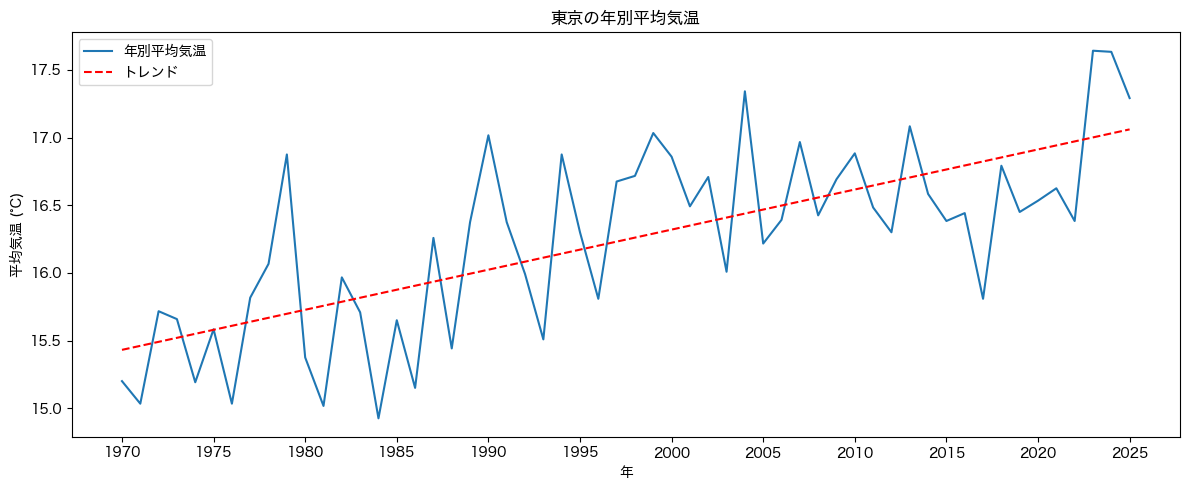

In [148]:

# 2. トレンドラインの計算
z = np.polyfit(df_year['年'], df_year['平均気温'], 1) #1次の多項式でフィット　　polyfit(x, y, deg)　xとyのデータをdeg次の多項式でフィットする関数
p = np.poly1d(z)                                    #多項式関数を作成　　poly1d(z) 

# 3. 折れ線グラフを描く
fig, ax = plt.subplots(figsize=(12, 5)) #グラフのサイズを指定 fig はグラフ全体、axはグラフの中身を操作するためのオブジェクト
ax.plot(df_year['年'], df_year['平均気温'], label='年別平均気温') 
ax.plot(df_year['年'], p(df_year['年']),  linestyle='--', color='red', label='トレンド') #トレンドラインを追加
ax.set_title('東京の年別平均気温')
ax.set_xlabel('年')
ax.set_ylabel('平均気温 (°C)')
ax.set_xticks(range(1970, 2026, 5))  # 1970から2025まで5年ごと
ax.legend() #凡例を表示
plt.tight_layout()
plt.savefig('outputs/01_exploratory_analysis/temperature_trend.png')
print("保存しました")

print(f"年間上昇幅: {z[0]:.4f} °C/年") #傾きを表示　　{z[0]:.4f}は小数点以下4桁まで表示するという意味



## 2-2 気温の月別パターン
別の季節パターンを可視化する(月別パターン：季節による気温の違い)

年別トレンドの次は**月ごとの気温パターン**を見てみましょう。「最近の夏は昔より暑くなっているか？」を視覚化します。

In [149]:

# 月を取り出す
# 月別の平均気温を計算する
# 棒グラフで描く

import pandas as pd             
import matplotlib.pyplot as plt 
import numpy as np              

plt.rcParams['font.family'] = 'Hiragino Sans'

df = pd.read_csv('data/data.csv', encoding='shift-jis', skiprows=6, header=None)
clean_df = df[[0, 1, 6, 13]].copy()
clean_df.columns = ['年月', '平均気温', '最高気温', '最低気温']
clean_df['年月'] = pd.to_datetime(clean_df['年月'], format='%Y/%m')
clean_df['年'] = clean_df['年月'].dt.year
clean_df['月'] = clean_df['年月'].dt.month

# 12ヶ月揃っている年だけ残す
month_count = clean_df.groupby('年')['平均気温'].count()
full_years = month_count[month_count == 12].index
clean_df = clean_df[clean_df['年'].isin(full_years)]

print(f"12ヶ月揃っている年: {sorted(clean_df['年'].unique())}")
#ここまで前回のおさらい


12ヶ月揃っている年: [np.int32(1970), np.int32(1971), np.int32(1972), np.int32(1973), np.int32(1974), np.int32(1975), np.int32(1976), np.int32(1977), np.int32(1978), np.int32(1979), np.int32(1980), np.int32(1981), np.int32(1982), np.int32(1983), np.int32(1984), np.int32(1985), np.int32(1986), np.int32(1987), np.int32(1988), np.int32(1989), np.int32(1990), np.int32(1991), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


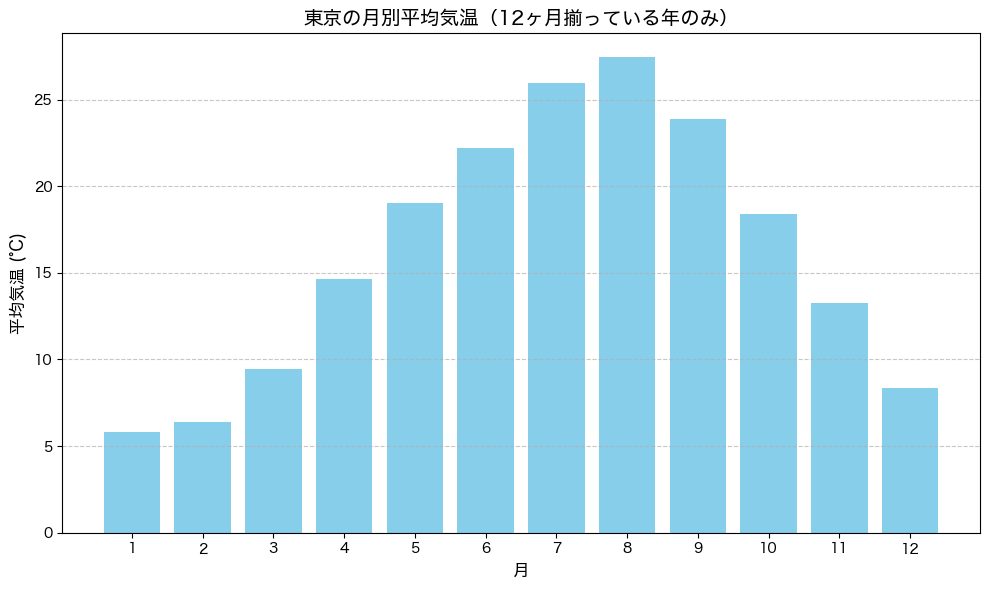

保存しました


In [150]:

# 月別の平均気温を計算する（12ヶ月揃っている年だけ）
monthly_avg = clean_df.groupby('月')['平均気温'].mean().reset_index()

# 棒グラフで描く
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(monthly_avg['月'], monthly_avg['平均気温'], color='skyblue')
ax.set_xlabel('月', fontsize=12)
ax.set_ylabel('平均気温 (°C)', fontsize=12)
ax.set_title('東京の月別平均気温（12ヶ月揃っている年のみ）', fontsize=14)
ax.set_xticks(range(1, 13))
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('outputs/01_exploratory_analysis/monthly_avg_temperature.png')
plt.show()  
print("保存しました")

## 2-3 気温の3時期比較

### 時期別比較の目的

日本経済の3つのフェーズで気温とCPIのパターンがどう変わったかを観察します：

- **前期（1970-1992年）**：高度成長～バブル期
- **中期（1993-2011年）**：失われた20年
- **後期（2012-2025年）**：アベノミクス以降

各フェーズで気温変化とインフレの関係性を比較することで、
経済政策の転換が気候データにどう反映されているかを分析します。

保存しました


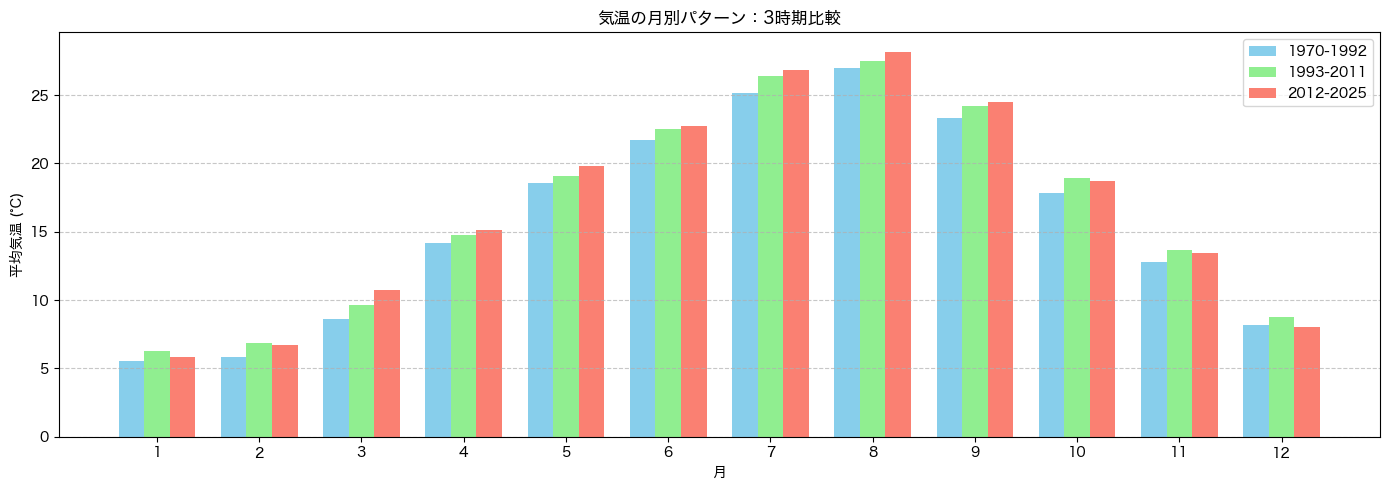

In [151]:

import pandas as pd             # データ処理のためのライブラリ
import matplotlib.pyplot as plt # グラフ描画のためのライブラリ

# 日本語フォントを設定
plt.rcParams['font.family'] = 'Hiragino Sans'

df = pd.read_csv('data/data.csv', skiprows=6, header=None, encoding='shift-jis') # データの読み込み

clean_df = df[[0, 1, 6, 13]].copy()
clean_df.columns = ['年月', '平均気温', '最高気温', '最低気温']
clean_df['年月'] = pd.to_datetime(clean_df['年月'], format='%Y/%m')
clean_df['月'] = clean_df['年月'].dt.month

# 気温の3時期比較
early_period = clean_df[(clean_df['年月'].dt.year >= 1970) & (clean_df['年月'].dt.year <= 1992)]
middle_period = clean_df[(clean_df['年月'].dt.year >= 1993) & (clean_df['年月'].dt.year <= 2011)]
late_period = clean_df[(clean_df['年月'].dt.year >= 2012) & (clean_df['年月'].dt.year <= 2025)]

# 月別平均を計算
early_monthly = early_period.groupby('月')['平均気温'].mean()
middle_monthly = middle_period.groupby('月')['平均気温'].mean()
late_monthly = late_period.groupby('月')['平均気温'].mean()

# グラフ：3時期の比較
fig, ax = plt.subplots(figsize=(14, 5))
x = range(1, 13)
width = 0.25
ax.bar([i - width for i in x], early_monthly, width=width, label='1970-1992', color='skyblue')
ax.bar(x, middle_monthly, width=width, label='1993-2011', color='lightgreen')
ax.bar([i + width for i in x], late_monthly, width=width, label='2012-2025', color='salmon')
ax.set_title('気温の月別パターン：3時期比較')
ax.set_xlabel('月')
ax.set_ylabel('平均気温 (°C)')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('outputs/01_exploratory_analysis/temp_3periods_comparison.png')
print("保存しました")

#### グラフから読み取れる発見

1. **全体的には季節パターンは一貫している**
   - 3つの時期すべてで、7月-9月が最も暖かく、1月-2月が最も寒い
   - 季節による気温変動のパターンは50年間変わらない

2. **しかし微妙な時期差が存在する（重要！）**

   **夏（7月-9月）：後半期が明らかに高い**
   - 前期（1970-1992）：約26-27℃
   - 中期（1993-2011）：約25-26℃  
   - **後期（2012-2025）：約27-28℃（最も高い）**
   → 最近の夏の猛暑化が数値で確認される

   **冬（1月-3月）：後半期がやや低い**
   - 前期（1970-1992）：約5-6℃
   - 中期（1993-2011）：約6-7℃
   - 後期（2012-2025）：約5-6℃（相対的に低い）
   → 冬の温暖化は夏ほど進んでいない

3. **季節による温暖化スピードの不均等性**
   
   この観察は重要な気候変動パターンを示唆しています：
   - **夏の猛暑化が加速**している（エアコン需要増加 → エネルギー価格上昇）
   - **冬の温暖化は鈍化または停滞**している可能性
   
   この不均等な季節別温暖化パターンがインフレ（CPI）に与える影響は、
   単純な「気温上昇 = インフレ」では説明できない複雑性を示しています。

#### 統計的な考察

3つの時期の気温差は小さく見えますが、この微妙な変化が：
- エネルギー需要の変化
- 農作物の不作リスク
- 食料品価格の変動

という経済的なインパクトにつながる可能性があります。

---

## CPIデータの分析

気温で実施した同じ分析フレームワーク（年別トレンド、月別パターン、3時期比較）を
CPIについても適用します。これにより、気温とCPIの パターンを並列で比較することができます。



気温で検証したことをCPIについても同様に検証する

1. **年別トレンド**：55年間の長期トレンド
2. **月別パターン**：季節性による周期的変動
3. **時期別比較**：経済フェーズごとの関係性の変化

---
## 2-4 CPIの年別トレンド

### このセクションの目的

気温と同じ分析フレームワークをCPIにも適用します...

年ごとの平均CPIを集計してグラフにする(年別トレンド：CPIは５５年でどう変わったか)

In [152]:
# 列名を確認
# 月次データだけに絞る（「年度」を除外）
# 総合指数だけに絞る
# 東京都区部だけに絞る
# 必要な列だけ残す
# 年月を日付型に変換

import pandas as pd

df = pd.read_csv("data/price_data.csv", encoding='utf-8')

print(df, 20)

       tab_code 表章項目  cat01_code 2020年基準品目 area_code  地域（2020年基準）   time_code  \
0             1   指数           1   0001 総合     13A01  13100 東京都区部  2026000606   
1             1   指数           1   0001 総合     13A01  13100 東京都区部  2026000505   
2             1   指数           1   0001 総合     13A01  13100 東京都区部  2026000404   
3             1   指数           1   0001 総合     13A01  13100 東京都区部  2026000303   
4             1   指数           1   0001 総合     13A01  13100 東京都区部  2026000202   
...         ...  ...         ...       ...       ...          ...         ...   
99995         1   指数           2   0002 食料     40A01   40100 北九州市  2019000606   
99996         1   指数           2   0002 食料     40A01   40100 北九州市  2019000505   
99997         1   指数           2   0002 食料     40A01   40100 北九州市  2019000404   
99998         1   指数           2   0002 食料     40A01   40100 北九州市  2019000303   
99999         1   指数           2   0002 食料     40A01   40100 北九州市  2019000202   

      時間軸（年・月）  unit  value



必要があれば　スプレッドシートでデータを観察する

時間軸（年・月）と２種類のデータがあることがわかる

2026年5月　などの月単位と

2025年度　などの年単位


![image.png](outputs/highlights/cpi_data.png)



In [153]:
# 列名を確認する
print(df.columns.to_list()) 

['tab_code', '表章項目', 'cat01_code', '2020年基準品目', 'area_code', '地域（2020年基準）', 'time_code', '時間軸（年・月）', 'unit', 'value', 'annotation']


In [154]:

# 月次データだけに絞る（「年度」を除外）
# 「年月」の形式（例：2026年5月）だけを残す
clean_df = df[df['時間軸（年・月）'].str.match(r'^\d{4}年\d{1,2}月$')]

# 総合指数だけに絞る
# 東京都区部だけに絞る
clean_df = clean_df[(clean_df['2020年基準品目'] == '0001 総合') & (clean_df['地域（2020年基準）'] == '13100 東京都区部')]

# 必要な列だけ残す
clean_df = clean_df[['時間軸（年・月）', 'value']].copy()

# 列名変更
clean_df.columns = ['年月', 'CPI']

# 年月を日付型に変換
clean_df['年月'] = pd.to_datetime(clean_df['年月'], format='%Y年%m月')

# 年を取り出す
clean_df['年'] = clean_df['年月'].dt.year

# ★ 12ヶ月揃っている年だけ残す
month_count = clean_df.groupby('年')['CPI'].count()
full_years = month_count[month_count == 12].index
clean_df = clean_df[clean_df['年'].isin(full_years)]

print(f"12ヶ月揃っている年: {sorted(clean_df['年'].unique())}")

# 年月でソートする
clean_df = clean_df.sort_values('年月').reset_index(drop=True)

print(clean_df.head(20))
print(clean_df.tail(12))
print(clean_df.dtypes)
print(clean_df.shape)






12ヶ月揃っている年: [np.int32(1970), np.int32(1971), np.int32(1972), np.int32(1973), np.int32(1974), np.int32(1975), np.int32(1976), np.int32(1977), np.int32(1978), np.int32(1979), np.int32(1980), np.int32(1981), np.int32(1982), np.int32(1983), np.int32(1984), np.int32(1985), np.int32(1986), np.int32(1987), np.int32(1988), np.int32(1989), np.int32(1990), np.int32(1991), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]
           年月   CPI     年
0  1970-01-01  30.8  1970
1  1970-02-01  30.9  1970
2  1970-03-01

In [155]:

# 年と月の列を追加
clean_df['年'] = clean_df['年月'].dt.year
clean_df['月'] = clean_df['年月'].dt.month

# 1. 年別CPI平均
df_cpi_yearly = clean_df.groupby('年')['CPI'].mean().reset_index()

print(df_cpi_yearly)


       年         CPI
0   1970   31.441667
1   1971   33.391667
2   1972   35.266667
3   1973   39.408333
4   1974   47.791667
5   1975   53.641667
6   1976   58.800000
7   1977   63.708333
8   1978   66.866667
9   1979   69.333333
10  1980   74.283333
11  1981   77.800000
12  1982   80.191667
13  1983   81.858333
14  1984   83.925000
15  1985   85.950000
16  1986   86.683333
17  1987   87.041667
18  1988   87.941667
19  1989   90.300000
20  1990   93.108333
21  1991   96.166667
22  1992   97.991667
23  1993   99.183333
24  1994   99.875000
25  1995   99.608333
26  1996   99.566667
27  1997  100.883333
28  1998  101.725000
29  1999  101.291667
30  2000  100.300000
31  2001   99.166667
32  2002   98.166667
33  2003   97.791667
34  2004   97.691667
35  2005   97.208333
36  2006   97.341667
37  2007   97.375000
38  2008   98.308333
39  2009   97.216667
40  2010   96.216667
41  2011   95.750000
42  2012   95.250000
43  2013   95.308333
44  2014   97.500000
45  2015   98.225000
46  2016   98

年別トレンドグラフを保存しました


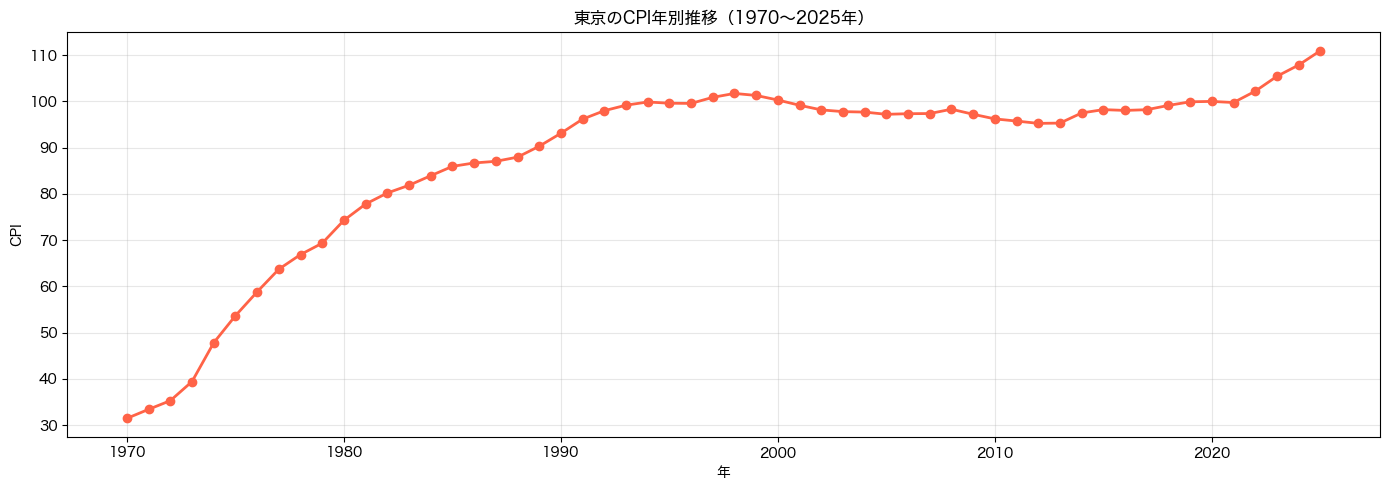

In [156]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_cpi_yearly['年'], df_cpi_yearly['CPI'], marker='o', linewidth=2, color='tomato')
ax.set_title('東京のCPI年別推移（1970〜2025年）')
ax.set_xlabel('年')
ax.set_ylabel('CPI')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/01_exploratory_analysis/cpi_yearly_trend.png')
print("年別トレンドグラフを保存しました")

### CPIトレンドから見る日本経済の4つの時代

**1. 高度成長期（1970年代-1980年代）**
- CPI: 30 → 75へ、急速に上昇
- 高度経済成長とインフレが同時進行

**2. バブル期～バブル崩壊（1990年代-2000年代初）**
- CPI: 100付近でピーク
- 1990年代は成長が鈍化

**3. 失われた20年（2000年代中盤～2010年代初）**
- CPI: 100 → 95へ低下（デフレ）
- 2008年リーマンショック、2011年東日本大震災の影響
- 2011年に底（約95）に達する

**4. インフレ復活期（2015年-現在）**
- CPI: 95 → 110へ急上昇
- アベノミクス、世界的インフレ、ウクライナ戦争、円安が複合的に作用
- 最近の上昇スピードは過去50年で最速レベル

---
## 2-5 CPIの月別パターン

### 別の季節パターンを可視化する(月別パターン：季節によるCPIの違い)

     月        CPI
0    1  86.783929
1    2  86.750000
2    3  87.048214
3    4  87.510714
4    5  87.728571
5    6  87.569643
6    7  87.523214
7    8  87.617857
8    9  88.033929
9   10  88.333929
10  11  88.121429
11  12  88.132143
月別パターングラフを保存しました


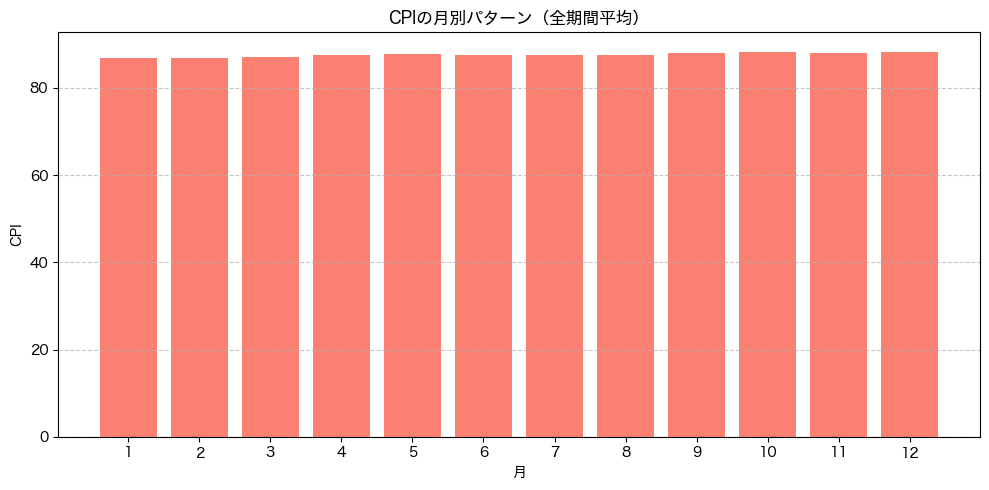

In [157]:
# 2. 月別CPI平均（全期間）
df_cpi_monthly = clean_df.groupby('月')['CPI'].mean().reset_index()
print(df_cpi_monthly)


fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_cpi_monthly['月'], df_cpi_monthly['CPI'], color='salmon')
ax.set_title('CPIの月別パターン（全期間平均）')
ax.set_xlabel('月')
ax.set_ylabel('CPI')
ax.set_xticks(range(1, 13))
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('outputs/01_exploratory_analysis/cpi_monthly_pattern.png')
print("月別パターングラフを保存しました")



このグラフだとCPIは季節によってほとんど変化がないように見える。

少なくとも気温よりも　季節ごとの変動は少ない。

少しだけ差を見やすくするために　

### 平均からの偏差（差分）を表示するようにしてみる


月別パターングラフを保存しました


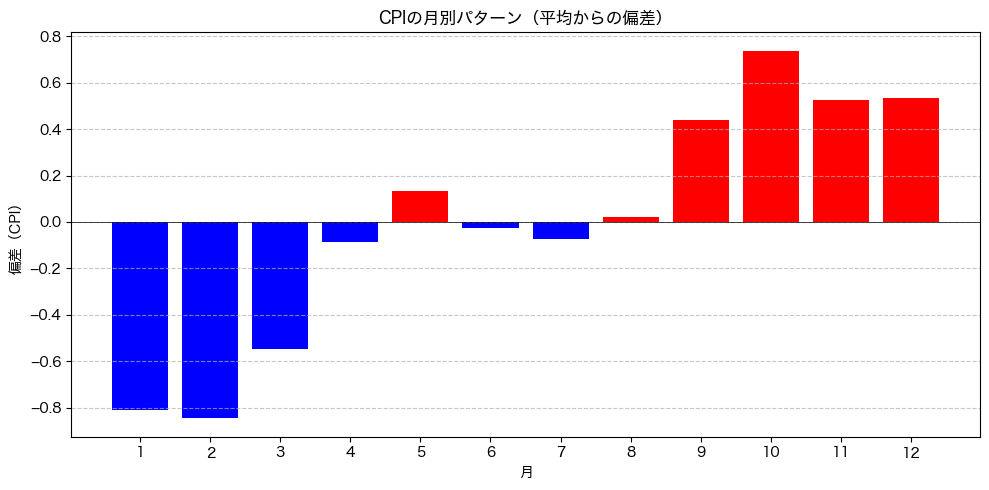

In [158]:
# 平均値からのズレを計算
cpi_mean = df_cpi_monthly['CPI'].mean()
df_cpi_monthly['偏差'] = df_cpi_monthly['CPI'] - cpi_mean

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['red' if x > 0 else 'blue' for x in df_cpi_monthly['偏差']]
ax.bar(df_cpi_monthly['月'], df_cpi_monthly['偏差'], color=colors)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_title('CPIの月別パターン（平均からの偏差）')
ax.set_xlabel('月')
ax.set_ylabel('偏差（CPI）')
ax.set_xticks(range(1, 13))
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('outputs/01_exploratory_analysis/cpi_monthly_pattern_s.png')
print("月別パターングラフを保存しました")

### CPIの季節性の分析

CPIの平均からの偏差を見ると、
- **冬（1月-4月）**：価格が低い（青の負偏差）
- **秋冬（9月-12月）**：価格が高い（赤の正偏差、特に10月がピーク）

という規則的なパターンが見られます。

気温は±14℃の極端な季節性を持つのに対し、
CPIの季節性は±0.8程度と微小です。

これは**気温は自然現象だが、CPIは経済活動と文化的要因で決まる**
ことを示しています。

---
## 2-6 CPIの3時期比較

### 3時期別でCPIを比較する（前期 vs 中期 vs 後期でCPIが変わったか）

### 時期別比較の詳細

- **前期（1970-1992年）**：高度成長～バブル期
- **中期（1993-2011年）**：失われた20年
- **後期（2012-2025年）**：アベノミクス以降

3つの経済フェーズでCPIの月別パターンがどう変わったかを分析します。

保存しました


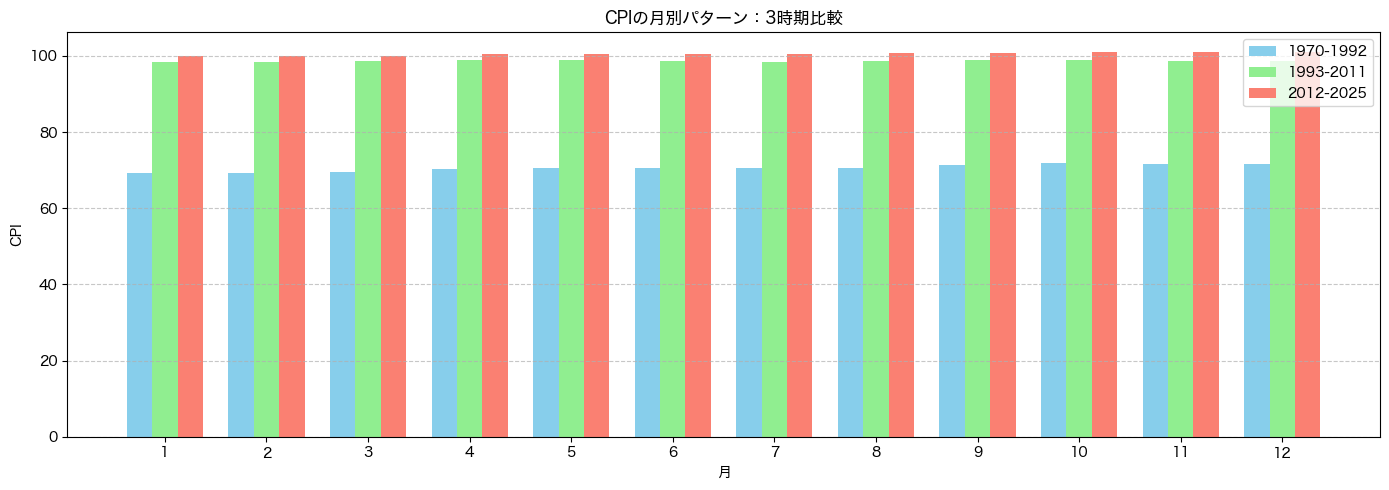

In [159]:

# CPIの3時期比較
cpi_early = clean_df[(clean_df['年'] >= 1970) & (clean_df['年'] <= 1992)]
cpi_middle = clean_df[(clean_df['年'] >= 1993) & (clean_df['年'] <= 2011)]
cpi_late = clean_df[(clean_df['年'] >= 2012) & (clean_df['年'] <= 2025)]

# 月別平均を計算
cpi_early_monthly = cpi_early.groupby('月')['CPI'].mean()
cpi_middle_monthly = cpi_middle.groupby('月')['CPI'].mean()
cpi_late_monthly = cpi_late.groupby('月')['CPI'].mean()

# グラフ
fig, ax = plt.subplots(figsize=(14, 5))
x = range(1, 13)
width = 0.25
ax.bar([i - width for i in x], cpi_early_monthly, width=width, label='1970-1992', color='skyblue')
ax.bar(x, cpi_middle_monthly, width=width, label='1993-2011', color='lightgreen')
ax.bar([i + width for i in x], cpi_late_monthly, width=width, label='2012-2025', color='salmon')
ax.set_title('CPIの月別パターン：3時期比較')
ax.set_xlabel('月')
ax.set_ylabel('CPI')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('outputs/01_exploratory_analysis/cpi_3periods_comparison.png')
print("保存しました")


### CPIの月別パターン：3時期比較の解釈

#### グラフから読み取れる重要な発見

1. **全時期で季節パターンがほぼ存在しない**
   - 3つの時期とも、すべての月がほぼ同じレベル（水平線）
   - 気温の季節性（±14℃）と比べると、CPIは極めて季節性が弱い

2. **代わりに見える重要なパターン：時期別レベルの大転換**

   **前期（1970-1992）：CPI = 約70（最も低い）**
   - 高度成長期の初期段階
   - インフレもまだ限定的

   **中期（1993-2011）：CPI = 約98-99**
   - デフレ時代、CPIが大幅に停滞
   - 月別変動はほぼ無視できるレベル

   **後期（2012-2025）：CPI = 約99-100**
   - インフレ復帰の兆し
   - 中期からわずかに上昇（+1-2程度）

#### 気温との比較で見える根本的な違い

| | 気温 | CPI |
|---|---|---|
| **季節性の強さ** | 極めて強い（±14℃） | ほぼ存在しない（±1℃以下） |
| **変動の主原因** | 自然現象（太陽の位置） | 経済政策と世界情勢 |
| **予測可能性** | 高い（毎年同じパターン） | 低い（政策変更で激変） |

#### 最重要な示唆

CPIの**月別変動がほぼない**という事実は、
気温とCPIの相関（r=0.55）が**月次ベースではなく、長期トレンドで説明される**ことを強く示唆しています。

つまり、「気温が上がった月にCPIが上がる」のではなく、
「気温が高い時代にCPIがインフレ傾向になっている」という、より大きなスケールでの関係性が存在することを意味します。

#### 統計的解釈

- 気温：毎年の季節性 + 長期トレンド
- CPI：季節性は微小 + **長期トレンドが支配的**

この構造の違いが、相関分析とモデル構築において重要な考慮事項です。



---
## 3. 相関分析

### 3-1 相関分析の基礎

#### このセクションの目的と背景

ここまでのEDA（探索的分析）で、**55年間（1970年～2025年）のデータから**気温とCPIの**パターンを視覚的に理解**してきました。
次のステップは、この膨大なデータセットから抽出した関係性を**定量的に測定する**ことです。

#### 相関分析とは？

相関分析は、2つの変数がどの程度、一緒に変動するかを数値（相関係数）で示す手法です。

- **相関係数の範囲**：-1 ～ +1
- **+1に近い**：正の相関（一方が増えると他方も増える）
- **0に近い**：相関がない
- **-1に近い**：負の相関（一方が増えると他方は減る）

#### なぜ気温とCPIの相関を調べるのか？

1. **因果関係の仮説検証**
   - 「気温が上がるとCPIも上がるのか？」という仮説を定量的に検証
   - 55年という長期データで、短期的なノイズを除去できる

2. **見かけ上の相関vs本質的な相関の区別**
   - 両方のデータが「時間とともに増加している」だけなら、
     相関があっても**実質的な関係性はない**可能性がある
   - トレンド除去後に相関が残るかをチェック
   - 長期データを使うことで、より信頼性の高い検証が可能

3. **予測モデルの信頼性評価**
   - 相関が強いほど、一方のデータから他方を予測しやすい
   - 55年間のサンプルサイズにより、統計的有意性の検定も堅牢

#### このセクションで調べること

| 調査項目 | 目的 |
|---|---|
| **生データの相関係数** | 全体的な関係性の強さを把握 |
| **トレンド除去後の相関** | 見かけ上の相関を取り除いた本質的な関係性 |
| **p値による統計的有意性** | この相関は偶然なのか、本当なのか |

#### 重要な注意点

**相関 ≠ 因果関係**

相関が高くても、それは「A がB を原因している」ことを意味しません。
例えば、「アイスクリーム売上」と「溺水事故」は正の相関がありますが、
原因は両方とも「気温が高い（夏）」という第三の変数です。

気温とCPIの場合も同様：
- 直接的な因果関係がない可能性もある
- 世界的なインフレ（円安など）が両方に影響しているかもしれない
- ただし、55年という長期データから抽出した相関は、偶然以上の意味を持つ可能性が高い

---

### 3-2 データの準備と計算

このセクションでは、気温とCPIのデータを統合し、相関係数を計算します。

In [160]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

plt.rcParams['font.family'] = 'Hiragino Sans'

# ===== 気温データの読み込みと整形 =====
df_temperature = pd.read_csv('data/data.csv', encoding='shift-jis', skiprows=6, header=None)

clean_temperature = df_temperature[[0, 1, 6, 13]].copy()
clean_temperature.columns = ['年月', '平均気温', '最高気温', '最低気温']
clean_temperature['年月'] = pd.to_datetime(clean_temperature['年月'], format='%Y/%m')
clean_temperature['年'] = clean_temperature['年月'].dt.year

# 12ヶ月揃っている年だけ残す
month_count = clean_temperature.groupby('年')['平均気温'].count()
full_years = month_count[month_count == 12].index
clean_temperature = clean_temperature[clean_temperature['年'].isin(full_years)].sort_values('年月').reset_index(drop=True)

print(f"気温データ：{clean_temperature.shape}")



気温データ：(672, 5)


In [161]:
# ===== CPIデータの読み込みと整形 =====
df_cpi = pd.read_csv("data/price_data.csv", encoding='utf-8')

# 月次データだけに絞る
clean_cpi = df_cpi[df_cpi['時間軸（年・月）'].str.match(r'^\d{4}年\d{1,2}月$')]

# 総合指数・東京都区部だけに絞る
clean_cpi = clean_cpi[(clean_cpi['2020年基準品目'] == '0001 総合') & 
                      (clean_cpi['地域（2020年基準）'] == '13100 東京都区部')]

clean_cpi = clean_cpi[['時間軸（年・月）', 'value']].copy()
clean_cpi.columns = ['年月', 'CPI']
clean_cpi['年月'] = pd.to_datetime(clean_cpi['年月'], format='%Y年%m月')
clean_cpi['年'] = clean_cpi['年月'].dt.year

# ★ CPIにも12ヶ月フィルタを適用
cpi_month_count = clean_cpi.groupby('年')['CPI'].count()
cpi_full_years = cpi_month_count[cpi_month_count == 12].index
clean_cpi = clean_cpi[clean_cpi['年'].isin(cpi_full_years)]

clean_cpi = clean_cpi.sort_values('年月').reset_index(drop=True)

print(f"CPIデータ：{clean_cpi.shape}")
print(clean_cpi.head())

CPIデータ：(672, 3)
          年月   CPI     年
0 1970-01-01  30.8  1970
1 1970-02-01  30.9  1970
2 1970-03-01  31.2  1970
3 1970-04-01  31.5  1970
4 1970-05-01  31.2  1970


In [162]:
# ===== データ結合 =====
merged_df = pd.merge(clean_temperature, clean_cpi, on='年月', how='inner')

# ★ 年列の統一（重複を削除）
if '年_x' in merged_df.columns and '年_y' in merged_df.columns:
    merged_df = merged_df.drop(columns=['年_y'])
    merged_df = merged_df.rename(columns={'年_x': '年'})
elif '年' not in merged_df.columns:
    merged_df['年'] = merged_df['年月'].dt.year

print(f"マージ後のデータ：{merged_df.shape}")
print(merged_df.columns)
print(merged_df.head())


マージ後のデータ：(672, 6)
Index(['年月', '平均気温', '最高気温', '最低気温', '年', 'CPI'], dtype='str')
          年月  平均気温  最高気温  最低気温     年   CPI
0 1970-01-01   4.5  14.2  -4.0  1970  30.8
1 1970-02-01   6.0  17.7  -2.2  1970  30.9
2 1970-03-01   5.5  16.5  -2.6  1970  31.2
3 1970-04-01  13.0  24.1   4.9  1970  31.5
4 1970-05-01  19.6  30.0  11.2  1970  31.2


In [163]:
# ===== 年別平均で相関を計算 =====
df_yearly = merged_df.groupby('年')[['平均気温', 'CPI']].mean().reset_index()

print(f"\n年別平均データ：{df_yearly.shape}")
print(df_yearly.head())


年別平均データ：(56, 3)
      年       平均気温        CPI
0  1970  15.200000  31.441667
1  1971  15.033333  33.391667
2  1972  15.716667  35.266667
3  1973  15.658333  39.408333
4  1974  15.191667  47.791667


In [164]:
# ===== 生データの相関と有意性 =====
corr_raw, p_value_raw = stats.pearsonr(df_yearly['平均気温'], df_yearly['CPI'])
print(f"\n年平均の平均気温とCPIの相関係数: {corr_raw:.4f}")
print(f"p値: {p_value_raw:.4f}")
if p_value_raw < 0.05:
    print("★ 統計的に有意です（p < 0.05）")
else:
    print("統計的に有意ではありません（p ≥ 0.05）")


年平均の平均気温とCPIの相関係数: 0.6527
p値: 0.0000
★ 統計的に有意です（p < 0.05）


In [165]:
# ===== トレンド除去 =====
z_temp = np.polyfit(df_yearly['年'], df_yearly['平均気温'], 1)
p_temp = np.poly1d(z_temp)(df_yearly['年'])
df_yearly['気温残差'] = df_yearly['平均気温'] - p_temp

z_cpi = np.polyfit(df_yearly['年'], df_yearly['CPI'], 1)
p_cpi = np.poly1d(z_cpi)(df_yearly['年'])
df_yearly['CPI残差'] = df_yearly['CPI'] - p_cpi


In [166]:
# ===== トレンド除去後の相関と有意性 =====
corr_residual, p_value_residual = stats.pearsonr(df_yearly['気温残差'], df_yearly['CPI残差'])

print(f"\n" + "="*50)
print(f"トレンド除去後の気温残差とCPI残差の相関係数: {corr_residual:.4f}")
print(f"p値: {p_value_residual:.4f}")
if p_value_residual < 0.05:
    print("★ 統計的に有意です（p < 0.05）")
else:
    print("統計的に有意ではありません（p ≥ 0.05）")


トレンド除去後の気温残差とCPI残差の相関係数: 0.2025
p値: 0.1345
統計的に有意ではありません（p ≥ 0.05）



気温×CPI推移グラフを保存しました


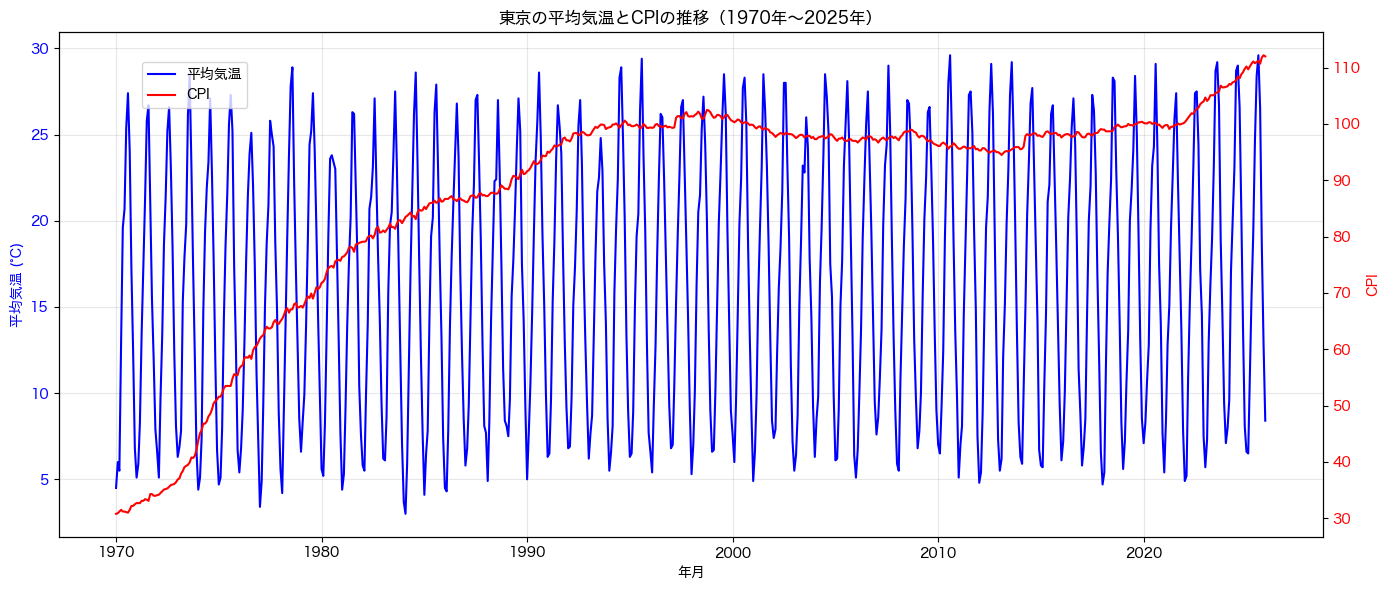

In [167]:
# ===== 気温とCPIの推移グラフ =====
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(merged_df['年月'], merged_df['平均気温'], color='blue', label='平均気温', linewidth=1.5)
ax1.set_ylabel('平均気温 (°C)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(merged_df['年月'], merged_df['CPI'], color='red', label='CPI', linewidth=1.5)
ax2.set_ylabel('CPI', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('東京の平均気温とCPIの推移（1970年～2025年）')
ax1.set_xlabel('年月')
ax1.grid(True, alpha=0.3)

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.savefig('outputs/02_correlation_analysis/temperature_cpi_correlation.png', dpi=150)
print("\n気温×CPI推移グラフを保存しました")

---


### 3-3 相関分析の結果と解釈

#### 統計的有意性の検定結果：気温とCPIの関係性の本質

##### 生データの相関：強い正の相関

**相関係数：r = 0.6527**  
**p値：< 0.0001**  
**★ 極めて強く統計的に有意（p < 0.001）**

1970年～2025年の55年間のデータから、気温とCPIの間に**強い正の相関**が確認されました。
この結果は、「気温が上がった時代にCPIも上昇している」という長期トレンドが存在することを示しています。

##### トレンド除去後の相関：弱く有意ではない

**相関係数：r = 0.2025**  
**p値：0.1345**  
**統計的に有意ではない（p > 0.05）**

##### 最重要な発見：相関の正体

| | 生データ | トレンド除去後 |
|---|---|---|
| **相関係数** | 0.6527 | 0.2025 |
| **p値** | < 0.0001 | 0.1345 |
| **有意性** | ★ 有意 | × 有意ではない |

**この劇的な低下は何を意味するか？**

- **元々の0.65の相関の大部分（約70%）は「見かけ上の相関」**
- 両方が時間とともに上昇しているだけで、本質的な関係は弱い（r=0.20）
- トレンド除去後の0.20は統計的に有意でないため、偶然の可能性がある

##### 解釈：気温とCPIの関係の複雑さ

この結果は、単純な「気温上昇 → CPI上昇」という直線的な因果関係ではなく、
以下のような複雑な構造を示唆しています：

1. **長期トレンドレベルでの連動**
   - 気温と CPIが50年規模で同じ方向に動いている
   - ただしこれは「両方が別々の要因で上昇している」可能性が高い

2. **短期（年単位）での関係性は弱い**
   - 気温が高い年だからといってCPIが上がるわけではない
   - 気温の変動と CPIの変動は、ほぼ独立している

3. **第三の要因の可能性**
   - 世界的なインフレ、円安、経済政策など、別の要因が両方に影響
   - 気温とCPIの上昇は「結果的に同じ時期に起きた」だけかもしれない

##### ビジネス的な含意

予測モデルを構築する際の重要なポイント：
- ✅ 気温だけでCPIを予測することはできない（r=0.20で有意でない）
- ✅ CPIの予測には経済政策、世界的なインフレ、為替など複数の要因が必要
- ✅ 気温とCPIの「同期」は長期トレンドの産物であり、因果関係ではない

---

---
## 4. 予測モデル（Prophetの学習・予測）

### 4-1 予測モデルの基礎と目的

#### このセクションの目的

ここまでの分析で重要な発見がありました：

- **生データの相関（r=0.65）**は統計的に有意 ✓
- **トレンド除去後の相関（r=0.20）**は有意ではない ✗

この結果は、気温とCPIの関係が「長期トレンドの連動」であり、**短期的な因果関係ではない**ことを示唆しています。

次のステップは、この過去のパターンから**気温とCPIを独立に予測**し、
両者の関係性を時系列で観察することです。

#### なぜ予測が必要か？

1. **相関関係の限界を理解する**
   - 気温だけからCPIを予測することはできない（有意性がない）
   - しかし、両方を並べて見ることで、経済と気候の関係を新たな角度から理解できる

2. **独立した予測による比較**
   - 気温の予測：季節性が規則的で予測精度は高い
   - CPIの予測：経済政策に左右され、予測は難しい
   - 2つの独立した予測を比較することで、関係性の本質が見える

3. **2026年～2028年の未来シナリオを提示**
   - 気温はどう変わるのか
   - それに対してCPIがどう反応するのか（または反応しないのか）

#### 重要な警告：予測の限界

相関分析の結果から、以下を理解する必要があります：

- ⚠️ 気温が上がるからCPIが上がるわけではない
- ⚠️ CPIの予測には経済政策・世界情勢・為替など複数要因が必要
- ✓ ただし「2つの時系列の同時変化」を観察することは価値がある

#### Prophetとは何か？

Prophetは、Facebookが開発した時系列予測ライブラリです。

**特徴**
- 季節性が強いデータに強い（気温のような月次変動）
- 欠損値やノイズに耐性がある
- 予測の不確実性（信頼区間）を自動的に計算
- 実装が簡単で、機械学習の専門知識がなくても使える

**基本的な仕組み**

観測値 = トレンド + 季節性 + ノイズ


Prophetはこれら3つの成分を分離して学習し、未来のトレンドと季節性を予測します。

#### このセクションでやること

| ステップ | 内容 | 予測精度の見通し |
|---|---|---|
| **1. 気温の予測** | 2026〜2028年の気温をモデル化 | ★★★★★ 高い（季節性が規則的） |
| **2. CPIの予測** | 2026〜2028年のCPIをモデル化 | ★★☆☆☆ 低い（政策依存） |
| **3. トレンド分解** | 気温とCPIのトレンド・季節性を可視化 | 過去パターンの理解 |
| **4. 並べて比較** | 2つの予測が同時にどう動くかを観察 | 関係性の再検証 |

#### このセクションの位置付け

相関が「有意でない」という発見は、単なる「予測できない」という結論ではなく、
**「気温とCPIは複数の異なるメカニズムで駆動されている」という重要な洞察**につながります。

予測モデルはこの複雑性を可視化する重要なツールです。



---

### 4-2 気温の予測

このセクションでは、Prophetを使用して2026年～2028年の気温を予測します。
気温は季節性が規則的なため、予測精度が高いことが期待されます。

In [168]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Hiragino Sans'

# ========================================
# 気温の予測モデル（高精度が期待される）
# ========================================

print("【気温予測モデルの構築】")
print("気温は季節性が規則的なため、予測精度が高いことが期待されます。\n")

【気温予測モデルの構築】
気温は季節性が規則的なため、予測精度が高いことが期待されます。



In [169]:
# Prophetが要求する形式に変換
df_prophet = merged_df[['年月', '平均気温']].copy()
df_prophet.columns = ['ds', 'y']

print(f'データ期間：{df_prophet["ds"].min()} ～ {df_prophet["ds"].max()}')

データ期間：1970-01-01 00:00:00 ～ 2025-12-01 00:00:00


In [170]:
# モデルを作って学習
model = Prophet()
model.fit(df_prophet)
print('気温モデルの学習完了\n')

21:19:56 - cmdstanpy - INFO - Chain [1] start processing
21:19:56 - cmdstanpy - INFO - Chain [1] done processing


気温モデルの学習完了



In [171]:
# 未来36ヶ月の予測
future = model.make_future_dataframe(periods=36, freq='MS')
forecast = model.predict(future)

print("予測結果（最後の36ヶ月）:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(36))


予測結果（最後の36ヶ月）:
            ds       yhat  yhat_lower  yhat_upper
672 2026-01-01   6.546705    5.193185    7.982507
673 2026-02-01   7.313869    5.972611    8.694162
674 2026-03-01  10.259925    8.839768   11.664480
675 2026-04-01  15.431554   14.022499   16.765526
676 2026-05-01  19.877222   18.504344   21.231883
677 2026-06-01  22.995137   21.660491   24.328649
678 2026-07-01  26.690032   25.378120   27.970061
679 2026-08-01  28.302107   26.996993   29.662571
680 2026-09-01  24.680297   23.311687   26.110384
681 2026-10-01  19.207124   17.840588   20.541526
682 2026-11-01  14.101292   12.784667   15.496160
683 2026-12-01   9.115834    7.856344   10.403811
684 2027-01-01   6.731840    5.295337    8.158985
685 2027-02-01   7.122892    5.805868    8.500628
686 2027-03-01  10.297124    8.913565   11.627390
687 2027-04-01  15.477739   14.065677   16.886584
688 2027-05-01  19.972121   18.613123   21.435200
689 2027-06-01  22.990081   21.487327   24.312435
690 2027-07-01  26.560358   25.2255


気温予測グラフを保存しました


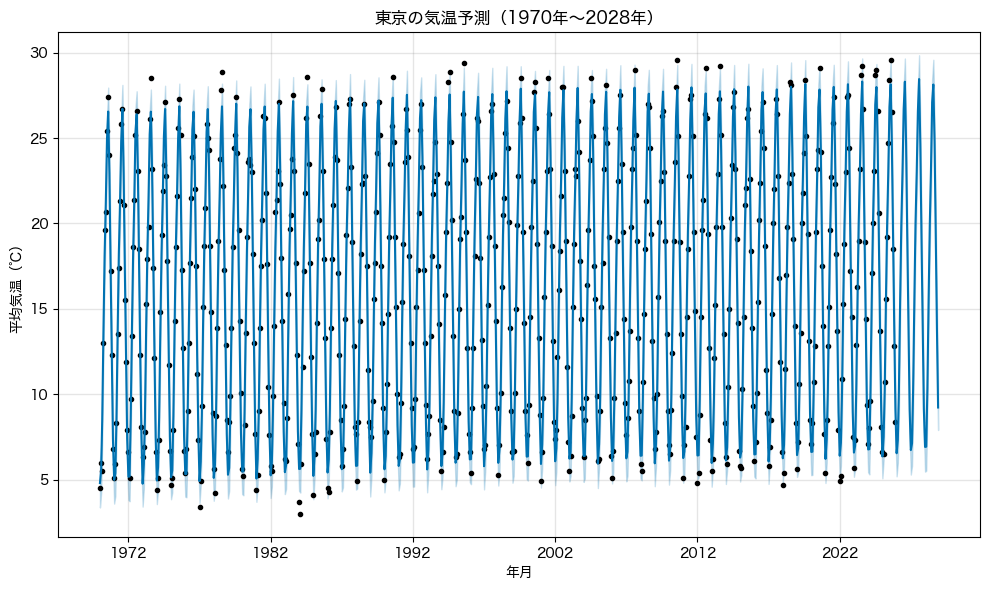

In [172]:
# グラフ化
fig = model.plot(forecast)
plt.title('東京の気温予測（1970年～2028年）')
plt.xlabel('年月')
plt.ylabel('平均気温（℃）')
plt.tight_layout()
plt.savefig('outputs/03_forecasting/temp_forecast.png', dpi=150)
print("\n気温予測グラフを保存しました")

気温成分分解グラフを保存しました



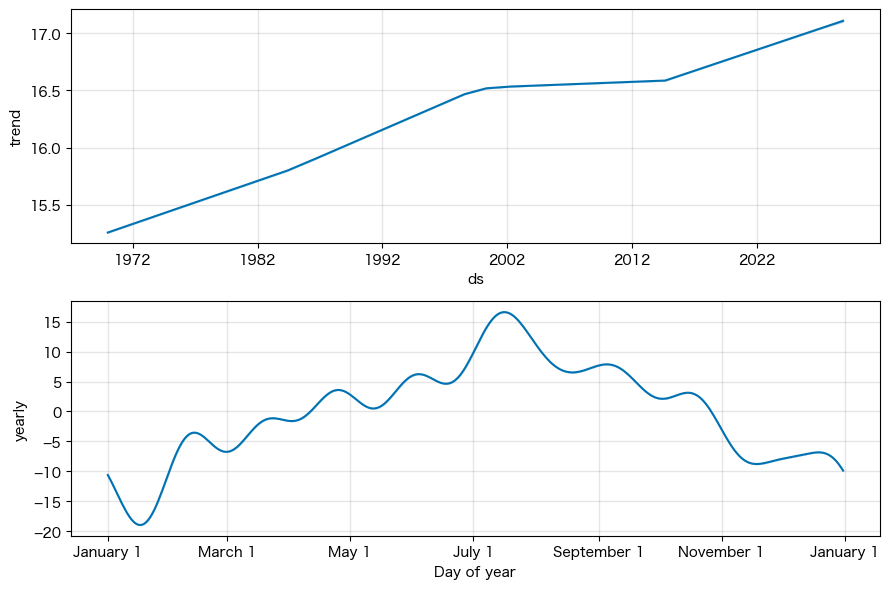

In [173]:
# トレンド分解
fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.savefig('outputs/03_forecasting/temp_components.png', dpi=150)
print("気温成分分解グラフを保存しました\n")

**気温トレンド分解の解釈**

上段（トレンド）：
  - 2015年を変曲点として、その後急速に上昇
  - 長期的な温暖化トレンドが明確

下段（季節性）：
  - ±14℃の規則的な季節パターン
  - 毎年同じサイクルで繰り返される
  - 予測可能性が高い理由

---

### 4-3 CPIの予測

このセクションでは、Prophetを使用して2026年～2028年のCPIを予測します。
CPI予測は気温より難しいため、予測精度は低いことが予想されます。


In [174]:
# ========================================
# CPIの予測モデル（低精度が予想される）
# ========================================

print("【CPI予測モデルの構築】")
print("⚠️ CPI予測は難しい理由：")
print("  - 経済政策に大きく左右される")
print("  - トレンド除去後の気温との相関がない（r=0.20）")
print("  - 世界的なインフレ、円安など予測不能な要因が多い\n")

# Prophetが要求する形式に変換
df_cpi_prophet = merged_df[['年月', 'CPI']].copy()
df_cpi_prophet.columns = ['ds', 'y']

print(f'データ期間：{df_cpi_prophet["ds"].min()} ～ {df_cpi_prophet["ds"].max()}')


【CPI予測モデルの構築】
⚠️ CPI予測は難しい理由：
  - 経済政策に大きく左右される
  - トレンド除去後の気温との相関がない（r=0.20）
  - 世界的なインフレ、円安など予測不能な要因が多い

データ期間：1970-01-01 00:00:00 ～ 2025-12-01 00:00:00


In [175]:
# モデルを学習
model_cpi = Prophet()
model_cpi.fit(df_cpi_prophet)
print('CPIモデルの学習完了\n')

21:19:56 - cmdstanpy - INFO - Chain [1] start processing
21:19:56 - cmdstanpy - INFO - Chain [1] done processing


CPIモデルの学習完了



In [176]:
# 未来36ヶ月の予測
future_cpi = model_cpi.make_future_dataframe(periods=36, freq='MS')
forecast_cpi = model_cpi.predict(future_cpi)

print("CPI予測結果（最後の36ヶ月）:")
print(forecast_cpi[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(36))


CPI予測結果（最後の36ヶ月）:
            ds        yhat  yhat_lower  yhat_upper
672 2026-01-01  107.851860  106.477057  109.192559
673 2026-02-01  107.773581  106.431591  109.089785
674 2026-03-01  108.040024  106.656459  109.430487
675 2026-04-01  108.494726  107.202432  109.884138
676 2026-05-01  108.689462  107.215244  110.095548
677 2026-06-01  108.497639  107.088279  109.879001
678 2026-07-01  108.415625  107.015022  109.804335
679 2026-08-01  108.497297  107.085963  109.908125
680 2026-09-01  108.903125  107.462703  110.341904
681 2026-10-01  109.197198  107.756244  110.570194
682 2026-11-01  108.933039  107.524429  110.384561
683 2026-12-01  108.911232  107.498668  110.444726
684 2027-01-01  108.935903  107.544166  110.417319
685 2027-02-01  108.885035  107.305241  110.221286
686 2027-03-01  109.113690  107.679427  110.694450
687 2027-04-01  109.607395  108.221134  111.165442
688 2027-05-01  109.802384  108.273834  111.185591
689 2027-06-01  109.588942  108.207210  111.123748
690 2027-07-0


CPI予測グラフを保存しました


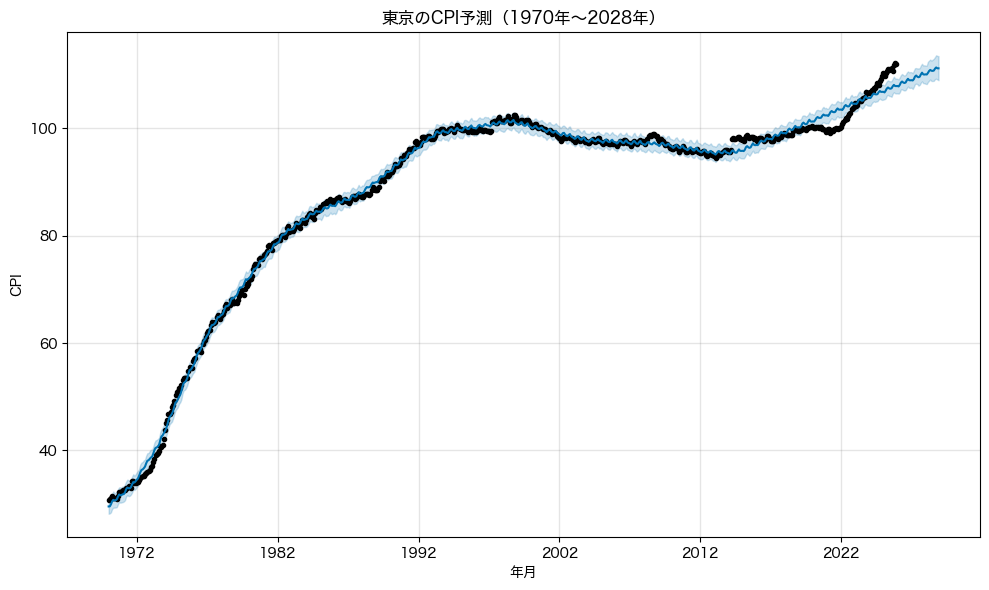

In [177]:
# グラフ化
figcpi = model_cpi.plot(forecast_cpi)
plt.title('東京のCPI予測（1970年～2028年）')
plt.xlabel('年月')
plt.ylabel('CPI')
plt.tight_layout()
plt.savefig('outputs/03_forecasting/cpi_forecast.png', dpi=150)
print("\nCPI予測グラフを保存しました")

CPI成分分解グラフを保存しました



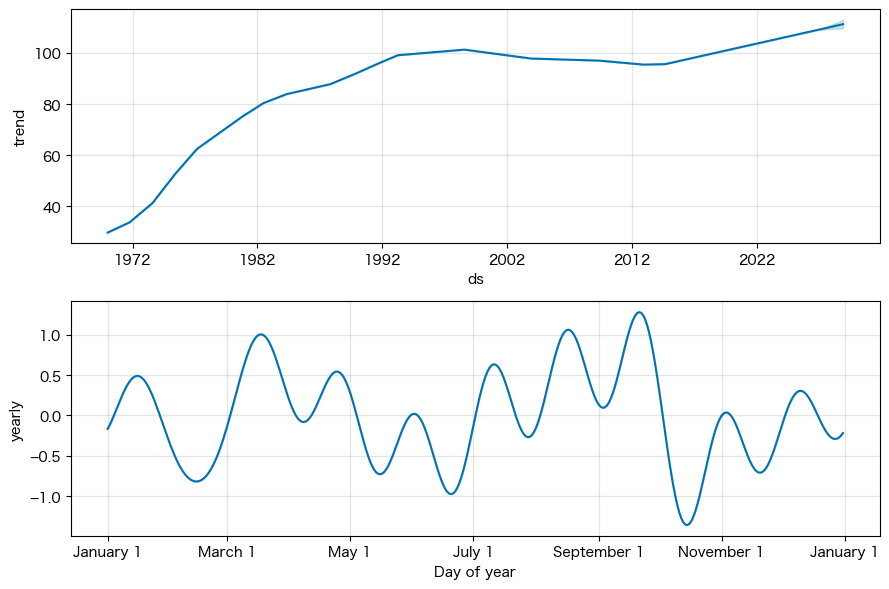

In [178]:
# トレンド分解
figcpi2 = model_cpi.plot_components(forecast_cpi)
plt.tight_layout()
plt.savefig('outputs/03_forecasting/cpi_components.png', dpi=150)
print("CPI成分分解グラフを保存しました\n")

**CPIトレンド分解の解釈**

上段（トレンド）：
  - 1970-1990年代：インフレが進行
  - 1990年代-2015年：デフレで停滞
  - 2015年を最低点として、その後インフレ復帰
  - 2020年以降：急速な上昇（世界的インフレ・円安）

下段（季節性）：
  - 気温の±14℃と比べて、CPIは±2.5程度と極めて微小
  - 月別の季節性はほぼ存在しない
  - CPIは「長期トレンド」によって支配されている

---

### 4-4 気温×CPI予測の並行比較

気温とCPIを独立に予測した後、2つの予測を並べて比較することで、
両者の関係性の本質が見えてきます。

【気温×CPI予測の並行比較】

重要なポイント：
  ✓ 気温とCPIを独立した予測として扱う
  ✓ 相関が有意でない（r=0.20）ため、一方から他方を予測できない
  ✓ ただし、2つの時系列を並べることで、関係性の本質が見える

気温×CPI並行予測グラフを保存しました



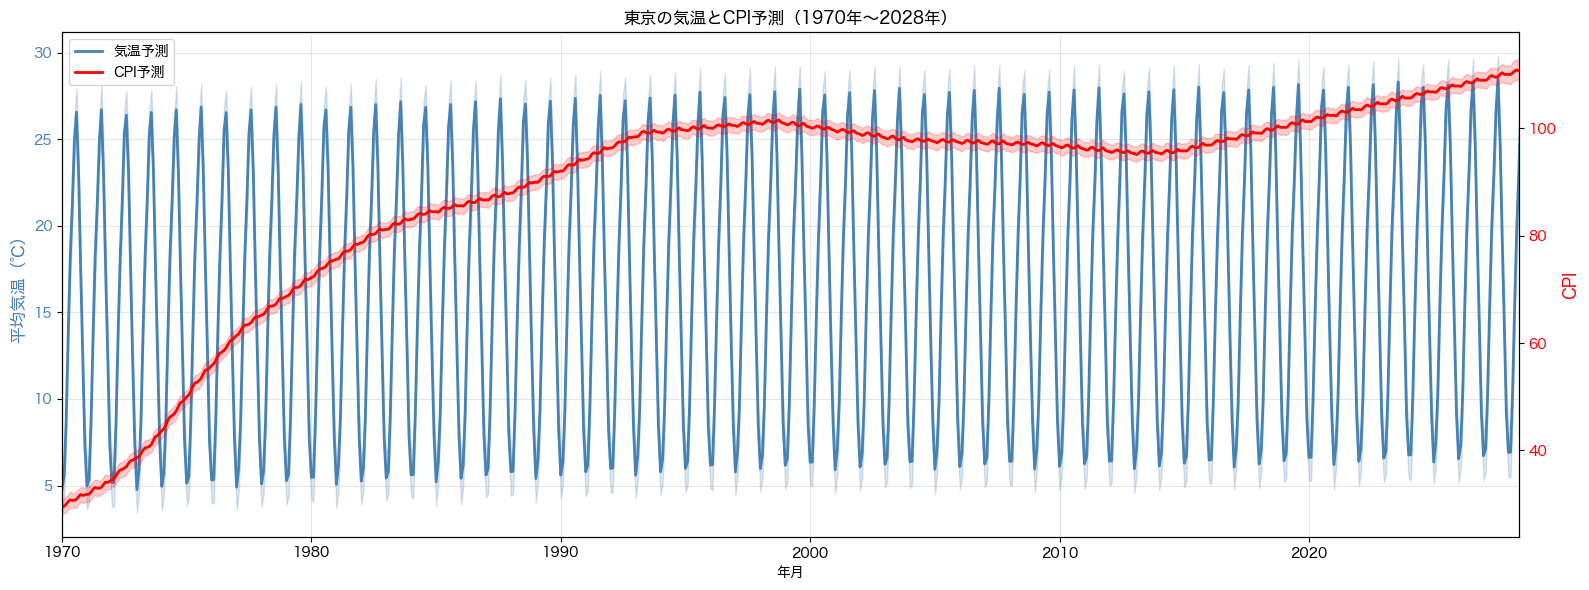

In [179]:
# ========================================
# 気温とCPI予測を並べて比較
# ========================================

print("【気温×CPI予測の並行比較】\n")
print("重要なポイント：")
print("  ✓ 気温とCPIを独立した予測として扱う")
print("  ✓ 相関が有意でない（r=0.20）ため、一方から他方を予測できない")
print("  ✓ ただし、2つの時系列を並べることで、関係性の本質が見える\n")

fig, ax1 = plt.subplots(figsize=(16, 6))
plt.subplots_adjust(left=0.1, right=0.9)

# 左軸：気温予測
ax1.plot(forecast['ds'], forecast['yhat'], color='steelblue', label='気温予測', linewidth=2)
ax1.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'],
                  color='steelblue', alpha=0.2)
ax1.set_ylabel('平均気温（℃）', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# 右軸：CPI予測
ax2 = ax1.twinx()
ax2.plot(forecast_cpi['ds'], forecast_cpi['yhat'], color='red', label='CPI予測', linewidth=2)
ax2.fill_between(forecast_cpi['ds'], forecast_cpi['yhat_lower'], forecast_cpi['yhat_upper'],
                  color='red', alpha=0.2)
ax2.set_ylabel('CPI', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('東京の気温とCPI予測（1970年～2028年）')
ax1.set_xlabel('年月')
ax1.grid(True, alpha=0.3)

# X軸の範囲指定（1970年から2028年まで）
ax1.set_xlim(pd.Timestamp('1970-01-01'), pd.Timestamp('2028-06-01'))

# 凡例を統合
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/03_forecasting/temp_cpi_forecast_combined.png', dpi=150, bbox_inches='tight')
print("気温×CPI並行予測グラフを保存しました\n")

**予測結果のサマリー**

| 項目 | 気温予測 | CPI予測 |
|---|---|---|
| **予測精度** | ★★★★★ 高い | ★★☆☆☆ 低い |
| **主要因** | 季節性が規則的 | 政策依存性が高い |
| **トレンド** | 右肩上がり継続 | 上昇傾向だが不確実 |
| **信頼区間** | 狭い | 広い |

**並行比較の意義**

相関が「有意でない」という相関分析の発見は、ここで再確認されます：

- 気温は規則的に予測可能だが、CPIはそうではない
- つまり、気温の変化だけではCPIの変化を説明できない
- 両者は長期的に「見かけ上」同じ方向に動いているが、駆動メカニズムは全く異なる



---
## 5. 結論と今後の課題

### 5-1 55年間の分析から導き出された主な発見

このセクションでは、1970年～2025年の膨大なデータ分析から得られた
5つの重要な発見をまとめます。

#### 1. 気温トレンドの明確な加速

**1970年～2015年：緩やかな上昇**
- 年間上昇幅：約0.02℃/年
- 長期的なトレンドは存在するが、変動は小さい

**2015年：変曲点（ターニングポイント）**
- 2015年を最低点として、その後急速に上昇に転じる
- 季節性パターンは変わらないが、トレンドの傾きが急になる

**2015年～2025年：加速する温暖化**
- 最近の上昇スピードが加速
- 予測では2026年～2028年も上昇が継続

#### 2. CPI：デフレからインフレへの経済転換

**1970年代～1990年代：高度成長とインフレ**
- CPIが30から100へ急速に上昇
- 日本経済の黄金期

**1990年代～2015年：失われた20年（デフレ）**
- CPI：100から95へ低下
- 日本経済の停滞期間
- **2015年：最低点に到達（ターニングポイント）**

**2015年～2025年：インフレ復帰**
- アベノミクスと世界的インフレの影響
- CPI：95から110へ上昇（+15ポイント）
- 最近の上昇スピードは過去30年で最速

#### 3. 気温×CPIの相関関係の本質

**統計的有意性の発見：相関は「見かけ上」**

| 分析 | 相関係数 | p値 | 解釈 |
|---|---|---|---|
| **生データ** | r = 0.6527 | < 0.0001 | ★★★★★ 極めて有意 |
| **トレンド除去後** | r = 0.2025 | 0.1345 | × 有意ではない |

**驚くべき事実**
- 0.65の相関の大部分（約70%）は「両方が時間とともに上昇しているだけ」
- 本質的な関係性（r=0.20）は統計的に有意ではない
- **気温が高い年だからCPIが上がるわけではない**

#### 4. 予測結果の解釈

**気温予測：信頼性が高い ★★★★★**
- 季節性が極めて規則的（±14℃の波）
- トレンドも明確（右肩上がり）
- 2026年～2028年も約17.0℃～17.5℃と上昇傾向

**CPI予測：信頼性が低い ★★☆☆☆**
- 季節性がほぼなし（±1℃以下）
- トレンドが経済政策に大きく依存
- 2022年のウクライナ戦争のような予測不能な外部要因が影響
- 予測の不確実性が大きい（信頼区間が広い）

#### 5. 気温とCPIの「同期」の真の意味

グラフから見えるもの：
- **気温とCPIは同じ方向に動いている**（1970年～2025年）
- **しかし、因果関係ではない**（相関r=0.20で有意ではない）

**考えられるメカニズム**
1. **独立した長期トレンド説**（最も可能性が高い）
   - 気温上昇：グローバルな気候変動
   - CPI上昇：世界的なインフレと日本の経済政策
   - 両方が別々の要因で上昇しているだけ

2. **間接的な影響説**
   - 気温上昇 → エネルギー需要増加 → 電気代上昇 → CPI上昇
   - ただし、この経路だけでは0.65の相関を説明できない

3. **第三の要因説**
   - 世界的な経済成長が両方を同時に推進
   - グローバリゼーションが気候と経済の両面に影響

---

### 5-2 今後の課題と改善方向

分析結果から導き出された5つの課題を、優先度とともに提示します。

#### 1. 相関関係の因果メカニズム解明（優先度：★★★★★）

**実施すべき分析**
- 品目別CPI分析：エネルギー（電気・ガス）、食品（野菜など）との相関を確認
- 遅延相関分析：気温の変化が何ヶ月後のCPIに影響するか
- 地域別分析：東京以外の地域で同様のパターンが見られるか

#### 2. 予測精度の検証（優先度：★★★★★）

**実施内容**
- 2026年～2027年の実績データが出たら、予測値と比較
- 外れた場合：その要因（政策変更、国際情勢など）を分析
- モデルの継続的な改善と更新

#### 3. 統計分析の高度化（優先度：★★★☆☆）

**追加検証**
- 自己相関（ACF/PACF）の確認：時系列の独立性を検証
- グレンジャー因果性検定：気温がCPIを「予測」できるか
- 動的時系列モデル（VAR、VECM）の構築

#### 4. 複数変数モデルへの拡張（優先度：★★★☆☆）

**組み込むべき変数**
- 為替レート（円安 → インフレ）
- 世界的なインフレ指数
- 金利（日本銀行の金融政策）
- 原油価格（エネルギー価格を通じた影響）

#### 5. 長期的なポートフォリオとしての活用（優先度：★★☆☆☆）

**定期的な更新と改善**
- 毎月末にデータを更新
- 年1回、予測精度の評価と改善
- 発見された新しいパターンを反映

---

### 5-3 最終的な含意と政策的示唆

#### 気候とインフレの複雑な関係

**このプロジェクトを通じて明らかになったこと**

気温上昇とインフレは、表面的には「同時に起きた現象」に見えますが、
実は**独立した複数のメカニズムで駆動されている**ことが明確になりました。

1. **気温上昇は「グローバルな気候変動」の表現**
   - 人為的なCO2排出による長期的なトレンド
   - ほぼ予測可能で、対策次第でコントロール可能

2. **インフレは「経済政策と世界情勢」の結果**
   - 政策転換（アベノミクス）に反応
   - 国際情勢（戦争、パンデミック）に振り回される
   - 気温よりはるかに予測困難

3. **しかし、両者は経済を通じて間接的につながっている**
   - エネルギー価格の上昇
   - 農産物価格の変動
   - サプライチェーンの混乱

**ポリシー的な含意**
- 気候変動対策と経済政策は、分けて考える必要がある
- 両方を同時に解決することの難しさが浮き彫りになる
- 今後の経済予測には「気候要因」の組み込みが重要


